In [1206]:
import os
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import FunctionTransformer
from scipy.stats import skew, kurtosis, zscore
from pyampute.exploration.mcar_statistical_tests import MCARTest
from scipy.stats import pointbiserialr
from scipy.stats import chi2_contingency
from sklearn.impute import KNNImputer, SimpleImputer

In [1207]:
FILE_PAHT = r'/Users/samuelsantiagosuarezpaez/Documents/Personal_Projects/data/titanic'

dfs = {}

for file in os.listdir(FILE_PAHT):
    if file.endswith('.csv'):
        file_full_paht = os.path.join(FILE_PAHT, file)
        dfs[file] = pd.read_csv(file_full_paht)
        print(f"Loaded file {file_full_paht} with shape: {dfs[file].shape}")

Loaded file /Users/samuelsantiagosuarezpaez/Documents/Personal_Projects/data/titanic/test.csv with shape: (418, 11)
Loaded file /Users/samuelsantiagosuarezpaez/Documents/Personal_Projects/data/titanic/train.csv with shape: (891, 12)
Loaded file /Users/samuelsantiagosuarezpaez/Documents/Personal_Projects/data/titanic/gender_submission.csv with shape: (418, 2)


In [1208]:
df_tr = dfs['train.csv']
df_ts = dfs['test.csv']
df_g = dfs['gender_submission.csv']

df_ts = pd.merge(df_ts, df_g, on='PassengerId')

In [1209]:
def basic_info(df):

    print("=" * 40)
    print("Shape:")
    print(df.shape)

    print("\n" + "=" * 40)
    print("Info:")
    df.info()

    print("\n" + "=" * 40)
    print("Missing values:")
    print(df.isna().sum())

    print("\n" + "=" * 40)
    print("Missing percentage:")
    print((df.isna().mean() * 100).round(2))

    print("\n" + "=" * 40)
    print("Duplicate rows:")
    print(df.duplicated().sum())

    print("\n" + "=" * 40)
    print("Unique values:")
    print(df.nunique())

    print("\n" + "=" * 40)
    print("Numerical summary:")
    print(df.describe())

    #print("\n" + "=" * 40)
    #print("Categorical summary:")
    #print(df.describe(include='object'))

In [1210]:
basic_info(df_tr)

Shape:
(891, 12)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked 

In [1211]:
df_tr.drop(columns=['Ticket','PassengerId','Name'], inplace=True)

## Categorical features

In [1212]:
df_tr.sample(4)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
823,1,3,female,27.0,0,1,12.4750,E121,S
640,0,3,male,20.0,0,0,7.8542,NaN,S
337,1,1,female,41.0,0,0,134.5000,E40,C
544,0,1,male,50.0,1,0,106.4250,C86,C


In [1213]:
df_tr.select_dtypes(include=['object','str']).sample(2)

,Sex,Cabin,Embarked
421,male,NaN,Q
794,male,NaN,S


In [1214]:
print(df_tr.Sex.value_counts())
df_tr['Sex'] = df_tr['Sex'].replace(['female','male'],[0,1]).astype(int)

Sex
male      577
female    314
Name: count, dtype: int64


In [1215]:
print(df_tr['Embarked'].value_counts())
print(df_tr['Embarked'].isna().sum())

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64
2


In [1216]:
df_tr['Embarked'] = df_tr['Embarked'].fillna(df_tr['Embarked'].mode()[0])

In [1217]:
df_tr['Cabin'].value_counts()

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F33            3
E101           3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

In [1218]:
df_tr['Cabin'].isna().sum()

np.int64(687)

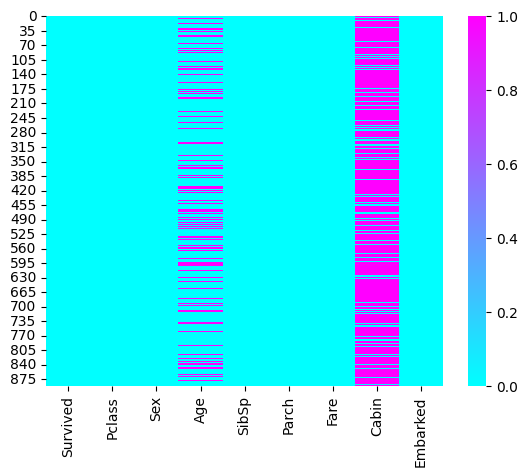

In [1219]:
sns.heatmap(df_tr.isnull(),cmap='cool');

In [1220]:
def missing_value (df):
    missing_Number = df.isnull().sum().sort_values(ascending=False)[df.isnull().sum().sort_values(ascending=False) !=0]
    missing_percent=round((df.isnull().sum()/df.isnull().count())*100,2)[round((df.isnull().sum()/df.isnull().count())*100,2) !=0]
    missing = pd.concat([missing_Number,missing_percent],axis=1,keys=['Missing Number','Missing Percentage'])
    return missing

missing_value(df_tr).style.background_gradient(cmap='coolwarm')

,Missing Number,Missing Percentage
Cabin,687,77.100000
Age,177,19.870000


In [1221]:
df_tr.drop(columns='Cabin', inplace=True)

In [1222]:
df_tr

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,S
1,1,1,0,38.0,1,0,71.2833,C
2,1,3,0,26.0,0,0,7.9250,S
3,1,1,0,35.0,1,0,53.1000,S
4,0,3,1,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,S
887,1,1,0,19.0,0,0,30.0000,S
888,0,3,0,NaN,1,2,23.4500,S
889,1,1,1,26.0,0,0,30.0000,C


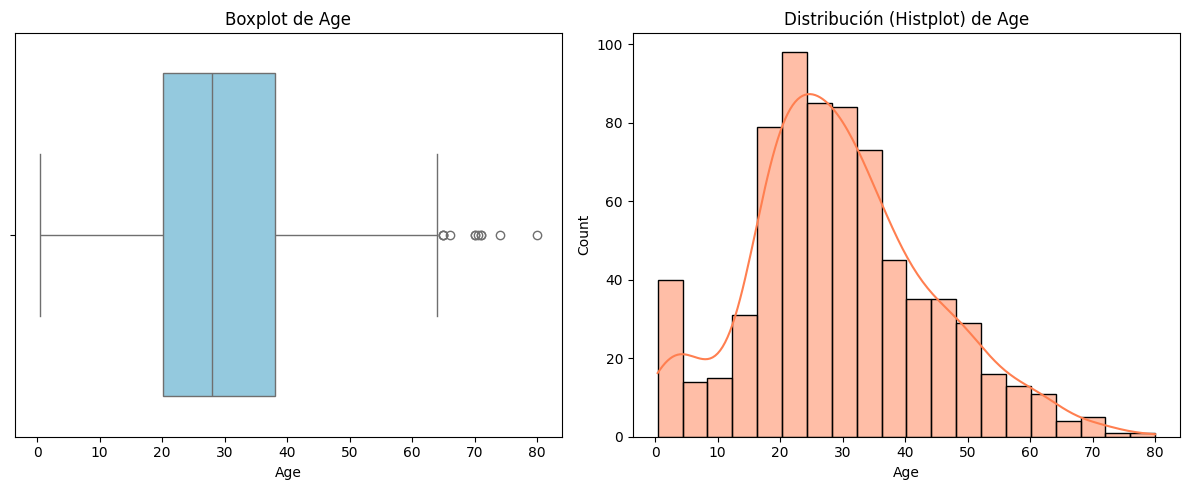

In [1223]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df_tr, x='Age', ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot de Age')

sns.histplot(data=df_tr, x='Age', kde=True, ax=axes[1], color='coral')
axes[1].set_title('Distribución (Histplot) de Age')

plt.tight_layout()
plt.show()

In [1224]:
age = df_tr['Age'].dropna()
 
# 1. Distribution screening
sk = skew(age)
ku = kurtosis(age)  # excess kurtosis (0 = normal)

print(f"Skewness: {sk:.3f}")
print(f"Excess Kurtosis: {ku:.3f}")

# 2. IQR method (robust, preferred if |skewness| > 0.5)
Q1, Q3 = age.quantile([0.25, 0.75])
IQR = Q3 - Q1
lower_iqr, upper_iqr = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers_iqr = age[(age < lower_iqr) | (age > upper_iqr)]

# 3. Z-score method (use if |skewness| < 0.5, approx. normal)
z = zscore(age)
outliers_z = age[np.abs(z) > 3]

# 4. Modified Z-score (robust alternative, MAD-based)
median = age.median()
mad = np.median(np.abs(age - median))
mod_z = 0.6745 * (age - median) / mad
outliers_modz = age[np.abs(mod_z) > 3.5]

# Summary
print(f"\nIQR bounds: [{lower_iqr:.2f}, {upper_iqr:.2f}]")
print(f"Outliers (IQR): {len(outliers_iqr)}")
print(f"Outliers (Z-score): {len(outliers_z)}")
print(f"Outliers (Modified Z-score): {len(outliers_modz)}")

Skewness: 0.388
Excess Kurtosis: 0.169

IQR bounds: [-6.69, 64.81]
Outliers (IQR): 11
Outliers (Z-score): 2
Outliers (Modified Z-score): 1


In [1225]:
# pip install pyampute (or use statsmodels alternative)

mt = MCARTest(method='little')
print(mt.little_mcar_test(df_tr.select_dtypes(exclude=['str'])))  # p < 0.05 → reject MCAR

3.0474388346135584e-08


In [1226]:
df_tr['Age_missing'] = df_tr['Age'].isna().astype(int)

# Numeric variables: t-test / correlation

corr, p = pointbiserialr(df_tr['Age_missing'], df_tr['Fare'])
print(f"Correlation with Fare: {corr:.3f}, p={p:.4f}")

# Categorical variables: chi-square test

ct = pd.crosstab(df_tr['Age_missing'], df_tr['Survived'])
chi2, p, dof, exp = chi2_contingency(ct)
print(f"Age missingness vs Survived: chi2={chi2:.3f}, p={p:.4f}")

Correlation with Fare: -0.101, p=0.0026
Age missingness vs Survived: chi2=7.106, p=0.0077


In [1227]:
df_tr.select_dtypes(exclude=['object','str']).sample(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Age_missing
742,1,1,0,21.0,2,2,262.375,0
748,0,1,1,19.0,1,0,53.100,0
209,1,1,1,40.0,0,0,31.000,0


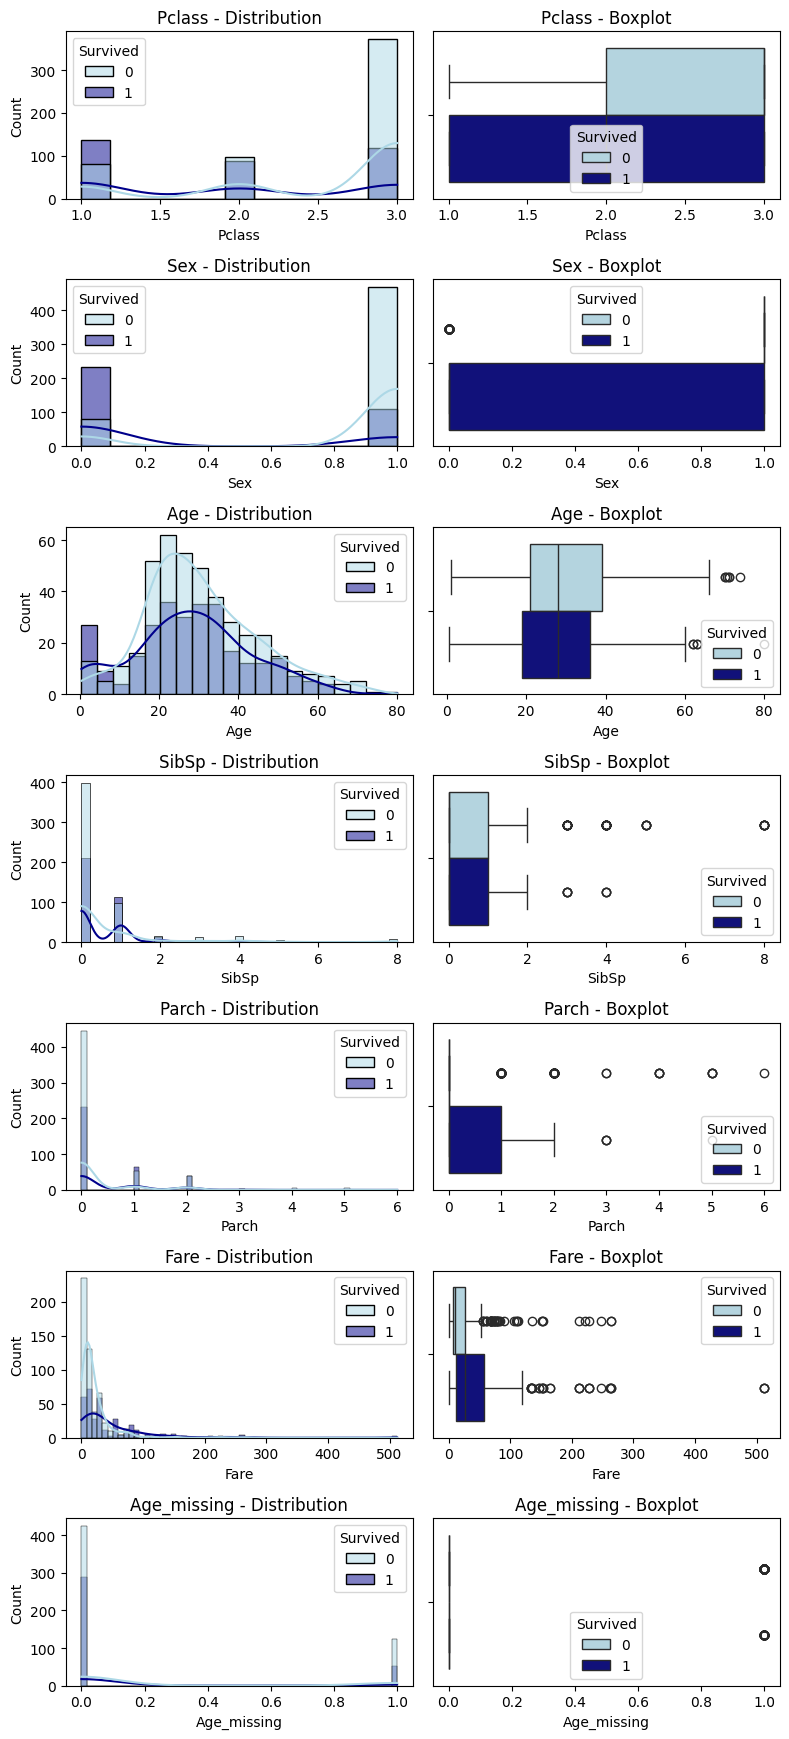

In [1228]:
num_cols = df_tr.select_dtypes(include='number').columns.drop('Survived')

palette = {
    0: 'lightblue',
    1: 'darkblue'
}

fig, ax = plt.subplots(
    len(num_cols), 2,
    figsize=(8, 2.5 * len(num_cols))
)

for i, col in enumerate(num_cols):

    sns.histplot(
        data=df_tr,
        x=col,
        hue='Survived',
        kde=True,
        palette=palette,
        ax=ax[i, 0]
    )

    sns.boxplot(
        data=df_tr,
        x=col,
        hue='Survived',
        palette=palette,
        ax=ax[i, 1]
    )

    ax[i, 0].set_title(f'{col} - Distribution')
    ax[i, 1].set_title(f'{col} - Boxplot')

plt.tight_layout()
plt.show()

In [1229]:
df_tr

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Age_missing
0,0,3,1,22.0,1,0,7.2500,S,0
1,1,1,0,38.0,1,0,71.2833,C,0
2,1,3,0,26.0,0,0,7.9250,S,0
3,1,1,0,35.0,1,0,53.1000,S,0
4,0,3,1,35.0,0,0,8.0500,S,0
...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,S,0
887,1,1,0,19.0,0,0,30.0000,S,0
888,0,3,0,NaN,1,2,23.4500,S,1
889,1,1,1,26.0,0,0,30.0000,C,0


In [1230]:
df_tr['Totalfamily'] = df_tr['SibSp'] + df_tr['Parch'] + 1

df_tr.Totalfamily.describe()

count    891.000000
mean       1.904602
std        1.613459
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       11.000000
Name: Totalfamily, dtype: float64

In [1231]:
# df['Totalfamily'] = df['Siblings/Spouses Aboard'] + df['Parents/Children Aboard'] + 1
fare_min, fare_max = df_tr['Fare'].min(), df_tr['Fare'].max()


def fare_group(number, low_thresh, high_thresh):
    if number <= low_thresh:
        return "Low_fare"
    elif number < high_thresh:
        return "normal_fare"
    else:
        return "Large_fare"


def family_size(number):
    if number==1:
        return "Alone"
    elif number>1 and number <5:
        return "Small"
    else:
        return "Large"

def age_group(number):
    if number< 15:
        return "Kid"
    elif number>15 and number <18:
        return "teenager"
    elif number>18 and number <60:
            return "adult"
    else:
        return "elderly"

def priority(row):
    if row['Age_group'] in ['Kid', 'teenager']:
        return 'High'
    elif row['Sex'] == 1:  
        return 'High'
    elif row['Age_group'] == 'elderly':
        return 'Medium'
    else:
        return 'Low'

#df['Familysize'] = df['Totalfamily'].apply(family_size)
#df['Fare_group'] = df['Fare'].apply(lambda x: fare_group(x, fare_min, fare_max))
#df['Age_group'] = df['Age'].apply(age_group)
#df['Priority'] = df.apply(priority, axis=1)

df_tr.describe()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Age_missing,Totalfamily
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.647587,29.699118,0.523008,0.381594,32.204208,0.198653,1.904602
std,0.486592,0.836071,0.477990,14.526497,1.102743,0.806057,49.693429,0.399210,1.613459
min,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,2.000000,0.000000,20.125000,0.000000,0.000000,7.910400,0.000000,1.000000
50%,0.000000,3.000000,1.000000,28.000000,0.000000,0.000000,14.454200,0.000000,1.000000
75%,1.000000,3.000000,1.000000,38.000000,1.000000,0.000000,31.000000,0.000000,2.000000
max,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200,1.000000,11.000000


In [1232]:
cols = ['Pclass', 'Sex','Totalfamily']

for col in cols:
    print('survival correlation ',col)
    df2 = df_tr.groupby(col)['Survived'].mean().reset_index()
    print(df2)


survival correlation  Pclass
   Pclass  Survived
0       1  0.629630
1       2  0.472826
2       3  0.242363
survival correlation  Sex
   Sex  Survived
0    0  0.742038
1    1  0.188908
survival correlation  Totalfamily
   Totalfamily  Survived
0            1  0.303538
1            2  0.552795
2            3  0.578431
3            4  0.724138
4            5  0.200000
5            6  0.136364
6            7  0.333333
7            8  0.000000
8           11  0.000000


In [1233]:
df_tr.isna().sum()

Survived         0
Pclass           0
Sex              0
Age            177
SibSp            0
Parch            0
Fare             0
Embarked         0
Age_missing      0
Totalfamily      0
dtype: int64

In [1234]:
cols_drop = ['SibSp','Parch','Age_missing']

df_tr = df_tr.drop(columns=cols_drop)

In [1235]:
df_tr

,Survived,Pclass,Sex,Age,Fare,Embarked,Totalfamily
0,0,3,1,22.0,7.2500,S,2
1,1,1,0,38.0,71.2833,C,2
2,1,3,0,26.0,7.9250,S,1
3,1,1,0,35.0,53.1000,S,2
4,0,3,1,35.0,8.0500,S,1
...,...,...,...,...,...,...,...
886,0,2,1,27.0,13.0000,S,1
887,1,1,0,19.0,30.0000,S,1
888,0,3,0,NaN,23.4500,S,4
889,1,1,1,26.0,30.0000,C,1


In [1236]:
X,Y = df_tr.drop(columns=['Survived']), df_tr['Survived']
X_train, X_test, y_train, y_test = train_test_split(X,Y, test_size=0.2, random_state=42,stratify=Y)

#cols_to_scale = ['Age', 'Fare','Siblings/Spouses Aboard','Parents/Children Aboard'] # Totalfamily
cols_to_scale = ['Age','Totalfamily','Sex','Pclass']
cols_logs = ['Fare']
cols_to_onehot = ['Embarked']#,'Fare_group','Familysize','Age_group','Priority']
features_to_impute = ['Age', 'Fare', 'Pclass','Sex','Totalfamily']

In [1237]:
num_cols = list(set(features_to_impute + cols_logs + cols_to_scale))
cat_cols = list(cols_to_onehot)

numeric_pipeline = Pipeline(steps=[
    ('knn_impute', KNNImputer(n_neighbors=5, weights='distance')),
    ('scale', StandardScaler())
])

log_scale_pipeline = Pipeline(steps=[
    ('impute', KNNImputer(n_neighbors=5, weights='distance')),
    ('log', FunctionTransformer(np.log1p, validate=False, feature_names_out="one-to-one")),
    ('scale', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, cols_to_scale),
        ('log_num', log_scale_pipeline, cols_logs),
        ('cat', cat_pipeline, cols_to_onehot)
    ],
    remainder='passthrough'
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7988826815642458
ROC-AUC: 0.8412384716732544

Confusion Matrix:
 [[89 21]
 [15 54]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.81      0.83       110
           1       0.72      0.78      0.75        69

    accuracy                           0.80       179
   macro avg       0.79      0.80      0.79       179
weighted avg       0.80      0.80      0.80       179



In [1238]:
param_grid = {'classifier__C':[0.01,0.1,1,10,100]}
grid = GridSearchCV(pipeline,param_grid, scoring='f1', cv=5)

grid.fit(X_train, y_train)
best_c = grid.best_params_['classifier__C']
print(grid.best_params_, grid.best_score_)

{'classifier__C': 1} 0.7319468910061552


In [1239]:
best_C = grid.best_params_['classifier__C']  

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, class_weight='balanced', C=best_C, max_iter=1000, solver='saga',penalty='l1'))
])

pipeline.fit(X_train, y_train)
y_prob = pipeline.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
print("Best threshold:", thresholds[best_idx], "F1:", f1_scores[best_idx])

y_pred = (y_prob >= thresholds[best_idx]).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
coefs = pipeline.named_steps['classifier'].coef_.ravel()

coefs_df = pd.DataFrame({'Feature': feature_names, 'Coef': coefs}) \
    .sort_values('Coef', key=abs, ascending=False)
coefs_df

Best threshold: 0.5468803371954374 F1: 0.7625899275575798
Accuracy: 0.8156424581005587
ROC-AUC: 0.8432147562582347

Confusion Matrix:
 [[93 17]
 [16 53]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85       110
           1       0.76      0.77      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



/Users/samuelsantiagosuarezpaez/Documents/Personal_Projects/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/samuelsantiagosuarezpaez/Documents/Personal_Projects/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,Feature,Coef
2,num__Sex,-1.198665
3,num__Pclass,-0.714511
0,num__Age,-0.576997
1,num__Totalfamily,-0.464542
4,log_num__Fare,0.449783
6,cat__Embarked_S,-0.288618
5,cat__Embarked_Q,0.079381


In [ ]:
best_C = grid.best_params_['classifier__C']  

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, class_weight='balanced', C=best_C, max_iter=1000, solver='saga',penalty='l1'))
])

pipeline.fit(X_train, y_train)
y_prob = pipeline.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
print("Best threshold:", thresholds[best_idx], "F1:", f1_scores[best_idx])

y_pred = (y_prob >= thresholds[best_idx]).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
coefs = pipeline.named_steps['classifier'].coef_.ravel()

coefs_df = pd.DataFrame({'Feature': feature_names, 'Coef': coefs}) \
    .sort_values('Coef', key=abs, ascending=False)
coefs_df

Best threshold: 0.5492068388958173 F1: 0.7571428566429591
Accuracy: 0.8100558659217877
ROC-AUC: 0.8412384716732543

Confusion Matrix:
 [[92 18]
 [16 53]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.84      0.84       110
           1       0.75      0.77      0.76        69

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



/Users/samuelsantiagosuarezpaez/Documents/Personal_Projects/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,Feature,Coef
2,num__Sex,-1.194980
3,num__Pclass,-0.718865
0,num__Age,-0.586080
1,num__Totalfamily,-0.475113
4,log_num__Fare,0.466416
6,cat__Embarked_S,-0.284284
5,cat__Embarked_Q,0.200280


In [1098]:
def cleaning(df):
    df = df.drop(columns=['Cabin'])
    df['Sex'] = df['Sex'].replace(['female', 'male'], [0, 1]).astype(int)
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    df['Totalfamily'] = df['SibSp'] + df['Parch'] + 1
    df = df.drop(columns=['SibSp', 'Parch'])
    return df

df_ts = cleaning(df_ts)

In [1099]:
X_final_test = df_ts[X_train.columns]  # ensure column match

test_pred = pipeline.predict(X_final_test)
test_prob = pipeline.predict_proba(X_final_test)[:, 1]

submission = pd.DataFrame({
    'PassengerId': df_ts['PassengerId'],
    'Survived': test_pred
})

In [1100]:
compare = pd.merge(df_g, submission, on= 'PassengerId')
compare['Score'] = (compare['Survived_x'] == compare['Survived_y']).astype(int)

In [1101]:
sum(compare['Score']) / compare.shape[0]


0.8947368421052632